In [39]:
import matplotlib.pyplot as plt

from brian2 import *
import scienceplots

In [40]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [41]:
seed(0)

In [42]:
# ----------------------- Models -----------------------
# --- Brian Equations ---
eqs_neurons = '''
r = clip(u, 0 * Hz, 100 * Hz) : Hz
dr_slow/dt = 1 / Tau_slow * (-r_slow + r**2) : Hz*Hz
du/dt = 1 / Tau * (-u + u_syn + u_r + r_ext) : Hz
du_r/dt = - Theta_ur * (u_r - U_r0) + (Sigma_ur * xi)*Hz : Hz
r_ext : Hz
u_syn : Hz
sum_w : 1
X : metre (constant)
Y : metre (constant)
U_r0 : Hz (constant)
Theta_ur : Hz (constant)
Sigma_ur : Hz**0.5 (constant)
Tau : second (constant)
Tau_slow : second (constant)
'''

eqs_syn = '''
dw = r_pre/Hz * r_post/Hz * (r_post - theta) : Hz (constant over dt)
ddelta_w/dt = 1 / Tau_W * (dw - delta_w) : Hz (clock-driven)
dw/dt = Lr * clip(
    delta_w * (int(delta_w < 0*Hz) * int(w > 0.01) + int(delta_w > 0*Hz) * int(w < 0.5)), 
    -30*17*15*Hz, 30*17*15*Hz)
    - 1 / C * int(sum_w_pre > W_sum_max * DEG) * int(w > 0.01) * (sum_w_pre - W_sum_max * DEG)
: 1 (clock-driven)
theta = r_slow_post / R_0 : Hz (constant over dt)
u_syn_post = w * r_pre : Hz (summed)
sum_w_pre = w : 1 (summed)
Lr : 1 (constant)
W_sum_max : 1 (constant)
R_0 : Hz (constant)
C : second (constant)
Tau_W : second (constant)
DEG : 1 (constant)
'''

In [43]:
def brain_sim(ws_init):

    neurons = NeuronGroup(3, eqs_neurons, method='euler')
    synapses = Synapses(neurons[0], neurons[1:], eqs_syn, method='euler')
    synapses.connect()

    neurons.Tau_slow = 1000*ms
    neurons.Tau = 10*ms
    neurons.u = 2*Hz
    neurons.Theta_ur = 1*Hz

    neurons[0].U_r0 = 2*Hz
    neurons[1].U_r0 = 2*Hz - 2*Hz * ws_init[0]
    neurons[2].U_r0 = 2*Hz - 2*Hz * ws_init[1]

    synapses.R_0 = 2*Hz
    synapses.w[:][0] = ws_init[0]
    synapses.w[:][1] = ws_init[1]
    synapses.DEG[:] = 2

    synapses.Lr = 1e-4
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 0.12
    synapses.C = 2_000*ms

    M = StateMonitor(neurons, ['r', 'r_slow'], record=False, dt=10*second)
    S = StateMonitor(synapses, ['w', 'theta', 'dw', 'delta_w'], record=False, dt=10*ms)
    net = Network(synapses, neurons, M, S)

    net.run(20*second)
    net.store("init")

    net.restore("init")
    n_steps = 400
    ws_sim = np.zeros((n_steps, 2))
    for i in range(n_steps):
        neurons[0].r_ext = 30*Hz 
        net.run(0.1*second)
        
        neurons[0].r_ext = 0*Hz
        net.run(5*second) 
        
        ws_sim[i] = synapses.w[:]
    return ws_sim

In [44]:
trajectories = [(0.05, 0.05), (0.04, 0.1), (0.04, 0.03)]

ws_brian_sim = []
for trajectory in trajectories:
    ws_brian_sim.append(brain_sim(trajectory))

KeyboardInterrupt: 

In [ ]:
def brain_sim_multiple(ws_init):
    n_output = ws_init.size
    neurons = NeuronGroup(n_output + 1, eqs_neurons, method='euler')
    synapses = Synapses(neurons[n_output], neurons[:n_output], eqs_syn, method='euler')
    synapses.connect()

    neurons.Tau_slow = 1000*ms
    neurons.Tau_slow = 1000*ms
    neurons.Tau = 10*ms
    neurons.u = 2*Hz
    neurons.Theta_ur = 1*Hz

    neurons[n_output].U_r0 = 2*Hz
    for i in range(n_output):
        neurons[i].U_r0 =2*Hz - 2*Hz * ws_init[i]

    synapses.R_0 = 2*Hz
    synapses.w[:] = ws_init
    synapses.DEG[:] = ws_init.size

    synapses.Lr = 1e-4
    synapses.Tau_W = 100*ms
    synapses.W_sum_max = 0.15
    synapses.C = 2_000*ms

    M = StateMonitor(neurons, ['r', 'r_slow'], record=True, dt=10*second)
    S = StateMonitor(synapses, ['w', 'theta', 'dw', 'delta_w'], record=True, dt=10*ms)
    net = Network(synapses, neurons, M, S)

    net.run(40*second)
    net.store("init")

    net.restore("init")
    n_steps = 200
    ws_sim = np.zeros((n_steps, ws_init.size))
    for i in range(n_steps):
        neurons[n_output].r_ext = 30*Hz 
        net.run(0.1*second)
        
        neurons[n_output].r_ext = 0*Hz
        net.run(5*second) 
        
        ws_sim[i] = synapses.w[:]
    return ws_sim, net, M, S

In [ ]:
ws_brian_multiple, net, M, S = brain_sim_multiple(np.clip(np.random.rand(10)*0.05, 0.01, 0.5) * 3)

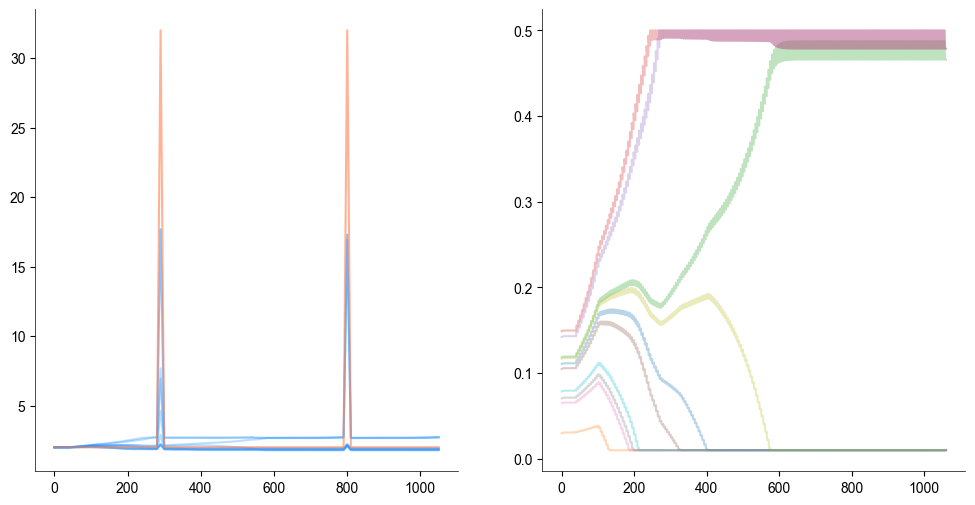

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(M.t, M.r[:-1].T, alpha=0.3, color='dodgerblue', linewidth=1.5)
axs[0].plot(M.t, M.r[-1].T, alpha=0.6, color='coral', linewidth=1.5)
axs[1].plot(S.t, S.w.T, alpha=0.3, linewidth=1.5)

plt.show()

In [ ]:
def simulate_trajectory(start_xs, n_runs, c2=0.2462):
    xs = np.array(start_xs, dtype=float)
    history = np.zeros((n_runs, xs.size))
    for i in range(n_runs):
        history[i] = xs
        # Growth step
        xs_growth = xs + c2 * np.power(xs, 2)
        # Mean-centering step
        m = np.mean(xs_growth)
        shift = max(0, m - 0.12)
        xs = np.clip(xs_growth - shift, 0.01, 0.5)
    return history

def get_delta_vectorized(X0, X1, c2=0.576):
    G0 = X0 + c2 * X0**2
    G1 = X1 + c2 * X1**2
    mean_G = (G0 + G1) / 2
    shift = np.where(mean_G > 0.12, mean_G - 0.12, 0)
    F0 = np.clip(G0 - shift, 0, 0.5)
    F1 = np.clip(G1 - shift, 0, 0.5)
    return F0 - X0, F1 - X1


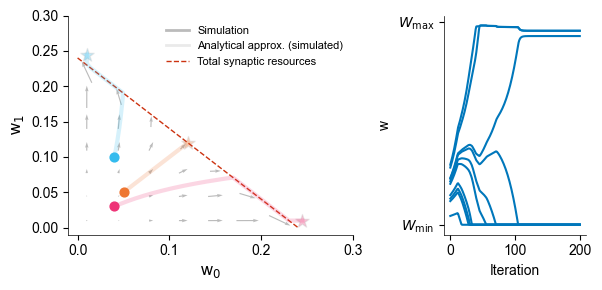

In [49]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic([["VF", "Stat"]], width_ratios=[2,1])

# Grid setup
x_range = np.linspace(0.01, 0.5, 15)
y_range = np.linspace(0.01, 0.5, 15)
X0, X1 = np.meshgrid(x_range, y_range)
mask = (X0 + X1 <= 0.241) # Keep vector field visualization mainly in growth zone

U, V = get_delta_vectorized(X0, X1)
U[~mask] = np.nan # Clean up field outside the target sum
V[~mask] = np.nan

# 1. Quiver Plot (Neutral gray)
axs["VF"].quiver(X0, X1, U, V, color=GRAY, alpha=1, pivot='mid', label='Growth Field')

# 2. Boundary Line
line_x = np.linspace(0, 0.24, 100)
axs["VF"].plot(line_x, 0.24 - line_x, '--', color=RED, linewidth=1, label='Total synaptic resources')

# 3. Specific Trajectories
colors = [ORANGE, LIGHT_BLUE, PINK]

for start, color in zip(trajectories, colors):
    traj = simulate_trajectory(start, n_runs=500)
    axs["VF"].plot(traj[:, 0], traj[:, 1], color=color, linewidth=3, label=f'Start {start}', alpha=0.2)
    axs["VF"].scatter(traj[0, 0], traj[0, 1], color=color, s=40)
    axs["VF"].scatter(traj[-1, 0], traj[-1, 1], color=color, s=100, marker="*", alpha=0.3, edgecolors=GRAY)

for traj, color in zip(ws_brian_sim, colors):
    axs["VF"].plot(traj[:,0],traj[:,1],color=color, linewidth=3, alpha=0.5)
    axs["VF"].scatter(traj[-1, 0], traj[-1, 1], color=color, s=100, marker="*", alpha=0.3, edgecolors="black")


axs["VF"].set_xlabel("w$_0$", fontsize=12)
axs["VF"].set_ylabel("w$_1$", fontsize=12)
axs["VF"].set_xlim(-0.01, 0.3)
axs["VF"].set_ylim(-0.01, 0.3)


axs["Stat"].plot(ws_brian_multiple, color=DARK_BLUE, linewidth=1.5)

axs["Stat"].set_ylabel('w')
axs["Stat"].set_xlabel('Iteration')
axs["Stat"].set_yticks([0.01, 0.5])
axs["Stat"].set_yticklabels([r"$W_{\min}$", r"$W_{\max}$"])


legend_elements = [
    # Method legend (gray, generic)
    Line2D([0], [0], color=GRAY, lw=2, label='Simulation'),
    Line2D([0], [0], color=GRAY, lw=2, label='Analytical approx. (simulated)',  alpha=0.3),
    Line2D([0], [0], color=RED, linestyle='--', linewidth=1, label='Total synaptic resources'),
]
axs["VF"].legend(handles=legend_elements, frameon=False, loc='upper right')


w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.)

fig.tight_layout()
if True:
    fig.savefig("fig_4C_FPs.pdf", dpi=300)

plt.show()